<a href="https://colab.research.google.com/github/P-Karthikeya512/Research-study-on-UNET/blob/main/fixed_kernel_UNET_DOOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

prabhalakarthikeya_doors_data_path = kagglehub.dataset_download('prabhalakarthikeya/doors-data')

print('Data source import complete.')


In [ ]:
import os
import glob
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model

from sklearn.model_selection import train_test_split

# =========================
# CONFIG
# =========================
IMG_SIZE = (128, 128)
BATCH_SIZE = 64
EPOCHS = 50
SEED = 42

# --- Kaggle paths (dataset is auto-extracted, no unzip needed) ---
IMAGE_DIR = "/kaggle/input/datasets/prabhalakarthikeya/doors-data/DOORS_data/img"
MASK_DIR  = "/kaggle/input/datasets/prabhalakarthikeya/doors-data/DOORS_data/mask"

# --- Kaggle output dir (this is what persists / can be downloaded) ---
OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Optional: confirm GPU is actually attached (Kaggle requires enabling it
# under Notebook Settings -> Accelerator, it isn't on by default)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

print("Images :", len(os.listdir(IMAGE_DIR)))
print("Masks  :", len(os.listdir(MASK_DIR)))

print(os.listdir(IMAGE_DIR)[:5])
print(os.listdir(MASK_DIR)[:5])

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Images : 35183
Masks  : 35183
['TR_011977.png', 'TR_014931.png', 'TR_017397.png', 'TR_012869.png', 'Te2_002212.png']
['TR_011977.png', 'TR_014931.png', 'TR_017397.png', 'TR_012869.png', 'Te2_002212.png']


In [ ]:
def get_pairs(image_dir, mask_dir):
    image_paths = []
    for ext in ["jpg", "jpeg", "png", "bmp", "tif", "tiff"]:
        image_paths.extend(glob.glob(os.path.join(image_dir, f"*.{ext}")))

    image_paths = sorted(image_paths)

    mask_map = {}
    for ext in ["jpg", "jpeg", "png", "bmp", "tif", "tiff"]:
        for p in glob.glob(os.path.join(mask_dir, f"*.{ext}")):
            stem = os.path.splitext(os.path.basename(p))[0]
            mask_map[stem] = p

    pairs = []
    for img_path in image_paths:
        stem = os.path.splitext(os.path.basename(img_path))[0]
        if stem in mask_map:
            pairs.append((img_path, mask_map[stem]))
        else:
            print(f"Warning: no mask found for {img_path}")

    return pairs


pairs = get_pairs(IMAGE_DIR, MASK_DIR)
print("Total paired samples:", len(pairs))


# =========================
# LOAD ONE IMAGE + MASK
# =========================
def load_image_mask(img_path, mask_path):
    # Image
    img = cv2.imread(img_path.decode(), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0

    # Mask
    mask = cv2.imread(mask_path.decode(), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"Could not read mask: {mask_path}")
    mask = cv2.resize(mask, IMG_SIZE, interpolation=cv2.INTER_NEAREST)

    # Binary mask: 0/1
    mask = (mask > 127).astype(np.float32)
    mask = np.expand_dims(mask, axis=-1)

    return img, mask


def tf_load_image_mask(img_path, mask_path):
    img, mask = tf.numpy_function(
        func=load_image_mask,
        inp=[img_path, mask_path],
        Tout=[tf.float32, tf.float32]
    )
    img.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])
    mask.set_shape([IMG_SIZE[0], IMG_SIZE[1], 1])
    return img, mask


# =========================
# AUGMENTATION
# =========================
def augment(image, mask):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    k = tf.random.uniform((), minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask = tf.image.rot90(mask, k)

    return image, mask


# =========================
# CREATE DATASET
# =========================
pairs = get_pairs(IMAGE_DIR, MASK_DIR)
print("Total paired samples:", len(pairs))

for img, mask in pairs[:3]:
    print(img)
    print(mask)
    print()


def make_dataset(pairs, training=True):
    img_paths = [p[0] for p in pairs]
    mask_paths = [p[1] for p in pairs]

    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    if training:
        ds = ds.shuffle(buffer_size=len(pairs), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(tf_load_image_mask, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, random_state=SEED)

train_ds = make_dataset(train_pairs, training=True)
val_ds = make_dataset(val_pairs, training=False)

print("Train samples:", len(train_pairs))
print("Val samples:", len(val_pairs))

Total paired samples: 35183
Total paired samples: 35183
/kaggle/input/datasets/prabhalakarthikeya/doors-data/DOORS_data/img/TR_000001.png
/kaggle/input/datasets/prabhalakarthikeya/doors-data/DOORS_data/mask/TR_000001.png

/kaggle/input/datasets/prabhalakarthikeya/doors-data/DOORS_data/img/TR_000002.png
/kaggle/input/datasets/prabhalakarthikeya/doors-data/DOORS_data/mask/TR_000002.png

/kaggle/input/datasets/prabhalakarthikeya/doors-data/DOORS_data/img/TR_000003.png
/kaggle/input/datasets/prabhalakarthikeya/doors-data/DOORS_data/mask/TR_000003.png



I0000 00:00:1786900062.832671      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786900062.835627      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Train samples: 28146
Val samples: 7037


In [ ]:
def dice_coef(y_true, y_pred, smooth=1e-7):
    y_true_f = tf.keras.backend.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = tf.keras.backend.flatten(tf.cast(y_pred, tf.float32))
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


def iou_coef(y_true, y_pred, smooth=1e-7):
    y_true_f = tf.keras.backend.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = tf.keras.backend.flatten(tf.cast(y_pred, tf.float32))
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

In [ ]:
@tf.keras.utils.register_keras_serializable()
class LearnableDepthwiseConv2D(layers.Layer):
    """
    Learnable depthwise kernel bank initialized with:
    - Sobel X
    - Sobel Y
    - Laplacian

    Input:  [B, H, W, C]
    Output: [B, H, W, 3C]
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        c = int(input_shape[-1])

        sobel_x = np.array([
            [-1, 0, 1],
            [-2, 0, 2],
            [-1, 0, 1]
        ], dtype=np.float32)

        sobel_y = np.array([
            [-1, -2, -1],
            [ 0,  0,  0],
            [ 1,  2,  1]
        ], dtype=np.float32)

        laplacian = np.array([
            [ 0,  1,  0],
            [ 1, -4,  1],
            [ 0,  1,  0]
        ], dtype=np.float32)

        # depthwise kernel shape: [kh, kw, in_channels, channel_multiplier]
        init_kernel = np.zeros((3, 3, c, 3), dtype=np.float32)

        for ch in range(c):
            init_kernel[:, :, ch, 0] = sobel_x
            init_kernel[:, :, ch, 1] = sobel_y
            init_kernel[:, :, ch, 2] = laplacian

        self.kernel = self.add_weight(
            name="kernel",
            shape=(3, 3, c, 3),
            initializer=tf.keras.initializers.Constant(init_kernel),
            trainable=True
        )

        super().build(input_shape)

    def call(self, x):
        return tf.nn.depthwise_conv2d(
            x,
            self.kernel,
            strides=[1, 1, 1, 1],
            padding="SAME"
        )

    def get_config(self):
        config = super().get_config()
        return config


# =========================================================
# LEARNABLE KERNEL BRANCH
# =========================================================
def learnable_kernel_block(x):
    x = LearnableDepthwiseConv2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x


def merge_with_learnable_kernels(feat, filters, prefix):
    """
    For a single skip tensor:
      original feature
      + learnable-kernel response of that feature
    Then concatenate and compress with 1x1 conv.
    """
    lk = LearnableDepthwiseConv2D(name=f"{prefix}_learnable")(feat)
    x = layers.Concatenate(name=f"{prefix}_concat")([feat, lk])

    x = layers.Conv2D(
        filters,
        1,
        padding="same",
        kernel_initializer="he_normal",
        name=f"{prefix}_compress"
    )(x)
    x = layers.ReLU(name=f"{prefix}_compress_relu")(x)
    return x


# =========================================================
# U-NET BLOCKS
# =========================================================
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x


def down_block(x, filters):
    c = conv_block(x, filters)
    p = layers.MaxPool2D((2, 2))(c)
    p = layers.Dropout(0.2)(p)
    return c, p


def up_block(x, skip, skip_learnable, filters):
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, skip, skip_learnable])
    x = layers.Dropout(0.2)(x)
    x = conv_block(x, filters)
    return x


# =========================================================
# BUILD MODEL
# =========================================================
def build_unet(input_shape=(128, 128, 3)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1, p1 = down_block(inputs, 32)
    c2, p2 = down_block(p1, 64)
    c3, p3 = down_block(p2, 128)
    c4, p4 = down_block(p3, 256)

    # Learnable-kernel transformed skips
    c1_star = merge_with_learnable_kernels(c1, 32, "c1")
    c2_star = merge_with_learnable_kernels(c2, 64, "c2")
    c3_star = merge_with_learnable_kernels(c3, 128, "c3")
    c4_star = merge_with_learnable_kernels(c4, 256, "c4")

    # Bottleneck
    bottleneck = conv_block(p4, 512)

    # Decoder
    u1 = up_block(bottleneck, c4, c4_star, 256)
    u2 = up_block(u1, c3, c3_star, 128)
    u3 = up_block(u2, c2, c2_star, 64)
    u4 = up_block(u3, c1, c1_star, 32)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(u4)

    model = Model(inputs, outputs, name="UNet_Binary_LearnableKernel")
    return model


model = build_unet()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=["accuracy", dice_coef, iou_coef]
)

model.summary()

Model: "UNet_Binary_LearnableKernel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 128, 128,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_18 (ReLU)     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 128, 128,  │      9,248 │ re_lu_18[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_19 (ReLU)     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ re_lu_19[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 64, 64,    │          0 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 64, 64,    │     18,496 │ dropout_8[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_20 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 64, 64,    │     36,928 │ re_lu_20[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_21 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ re_lu_21[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_5[

 Total params: 8,916,833 (34.02 MB)

 Trainable params: 8,910,945 (33.99 MB)

 Non-trainable params: 5,888 (23.00 KB)

Epoch 1/50


2026-08-16 17:09:11.086659: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-16 17:09:11.395748: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-16 17:09:14.127384: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-16 17:09:14.498825: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-16 17:09:17.835126: E external/local_xla/xla/stream_

439/440 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.7286 - dice_coef: 0.5183 - iou_coef: 0.3543 - loss: 0.4817

2026-08-16 17:13:53.682768: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-16 17:13:53.983004: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-16 17:13:56.620461: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-16 17:13:57.005104: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-16 17:13:57.057956: E external/local_xla/xla/service

440/440 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.7287 - dice_coef: 0.5184 - iou_coef: 0.3545 - loss: 0.4816
Epoch 1: val_dice_coef improved from None to 0.61614, saving model to /kaggle/working/best_unet.keras

Epoch 1: finished saving model to /kaggle/working/best_unet.keras
440/440 ━━━━━━━━━━━━━━━━━━━━ 412s 740ms/step - accuracy: 0.7525 - dice_coef: 0.5822 - iou_coef: 0.4134 - loss: 0.4179 - val_accuracy: 0.7607 - val_dice_coef: 0.6161 - val_iou_coef: 0.4453 - val_loss: 0.3839 - learning_rate: 1.0000e-04
Epoch 2/50
440/440 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.8067 - dice_coef: 0.6638 - iou_coef: 0.4971 - loss: 0.3362
Epoch 2: val_dice_coef improved from 0.61614 to 0.70659, saving model to /kaggle/working/best_unet.keras

Epoch 2: finished saving model to /kaggle/working/best_unet.keras
440/440 ━━━━━━━━━━━━━━━━━━━━ 230s 523ms/step - accuracy: 0.8227 - dice_coef: 0.6829 - iou_coef: 0.5189 - loss: 0.3171 - val_accuracy: 0.8359 - val_dice_coef: 0.7066 - val_iou_coef: 

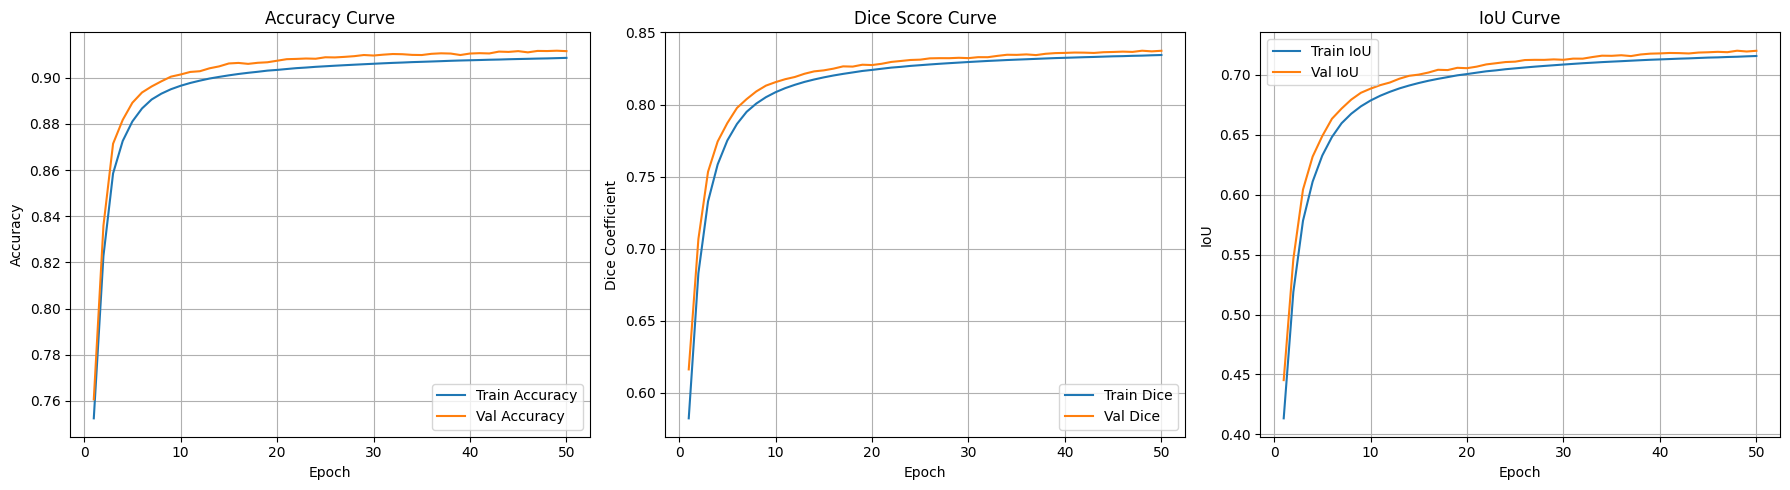

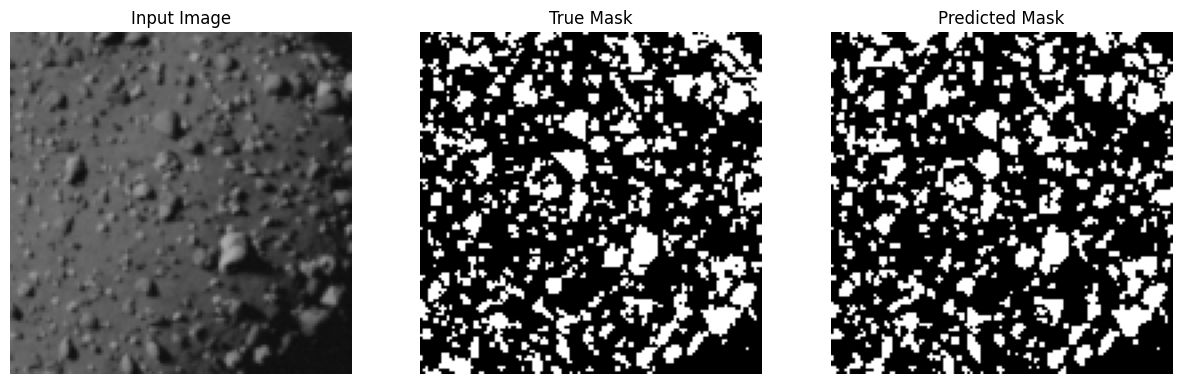

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_DIR, "best_unet.keras"),
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coef",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_dice_coef",
        mode="max",
        factor=0.5,
        patience=4,
        verbose=1
    )
]

# =========================
# TRAIN
# =========================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


# =========================
# PLOTS: ACCURACY, DICE, IOU
# =========================
def plot_training_curves(history):
    hist = history.history
    epochs_range = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs_range, hist["accuracy"], label="Train Accuracy")
    plt.plot(epochs_range, hist["val_accuracy"], label="Val Accuracy")
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, hist["dice_coef"], label="Train Dice")
    plt.plot(epochs_range, hist["val_dice_coef"], label="Val Dice")
    plt.title("Dice Score Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Dice Coefficient")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(epochs_range, hist["iou_coef"], label="Train IoU")
    plt.plot(epochs_range, hist["val_iou_coef"], label="Val IoU")
    plt.title("IoU Curve")
    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    # Save the figure to Kaggle's persistent output dir too
    plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"))
    plt.show()


plot_training_curves(history)


# =========================
# PREDICTION + VISUALIZATION
# =========================
def show_prediction(model, pair):
    img_path, mask_path = pair
    img, mask = load_image_mask(img_path.encode(), mask_path.encode())

    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
    pred_mask = (pred > 0.5).astype(np.uint8)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask.squeeze(), cmap="gray")
    plt.title("True Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask.squeeze(), cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.show()


# Show one validation sample
show_prediction(model, val_pairs[0])